# Parallel Gripper Grasping Demo
Simulates a parallel gripper picking an object off a table in MuJoCo and renders the result as a video.

In [1]:
import os, sys, time

os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import mujoco
import mediapy as media
import matplotlib.pyplot as plt

# Point to the XML
XML_PATH = '../gripper_sim/gripper.xml'
assert os.path.exists(XML_PATH), f"Not found: {XML_PATH}"

In [2]:

model = mujoco.MjModel.from_xml_path(XML_PATH)
data  = mujoco.MjData(model)
mujoco.mj_resetData(model, data)

renderer = mujoco.Renderer(model, height=480, width=640)
print('Model loaded.  nu =', model.nu, ' nq =', model.nq)

Model loaded.  nu = 3  nq = 10


In [ ]:

IDX_Z, IDX_LEFT, IDX_RIGHT = 0, 1, 2

def set_ctrl(z, left, right):
    data.ctrl[IDX_Z]     = z
    data.ctrl[IDX_LEFT]  = left
    data.ctrl[IDX_RIGHT] = right

def object_z():
    sid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, 'object_site')
    return data.site_xpos[sid, 2]

def capture():
    renderer.update_scene(data)
    return renderer.render().copy()

In [4]:

#  (name, z_target, left_finger, right_finger, duration_seconds)
PHASES = [
    ('OPEN',    0.00, 0.00, 0.00, 0.5),
    ('DESCEND',-0.27, 0.00, 0.00, 1.5),
    ('CLOSE',  -0.27, 0.05, 0.05, 1.0),
    ('LIFT',    0.00, 0.05, 0.05, 2.0),
    ('HOLD',    0.00, 0.05, 0.05, 1.5),
]

RECORD_EVERY = 10  # capture one frame every N steps
frames = []
phase_log = []

for phase_name, z_tgt, l_tgt, r_tgt, duration in PHASES:
    t_end = data.time + duration
    step  = 0
    while data.time < t_end:
        set_ctrl(z_tgt, l_tgt, r_tgt)
        mujoco.mj_step(model, data)
        if step % RECORD_EVERY == 0:
            frames.append(capture())
        step += 1
    phase_log.append((phase_name, object_z()))
    print(f'[{phase_name:8s}]  object z = {object_z():.4f} m')

print(f'\nTotal frames recorded: {len(frames)}')

[OPEN    ]  object z = 0.4500 m
[DESCEND ]  object z = 0.4495 m
[CLOSE   ]  object z = 0.4495 m
[LIFT    ]  object z = 0.6069 m
[HOLD    ]  object z = 0.6049 m

Total frames recorded: 328


In [5]:
fps = int(1 / model.opt.timestep / RECORD_EVERY)
media.show_video(frames, fps=fps)

This browser does not support the video tag.


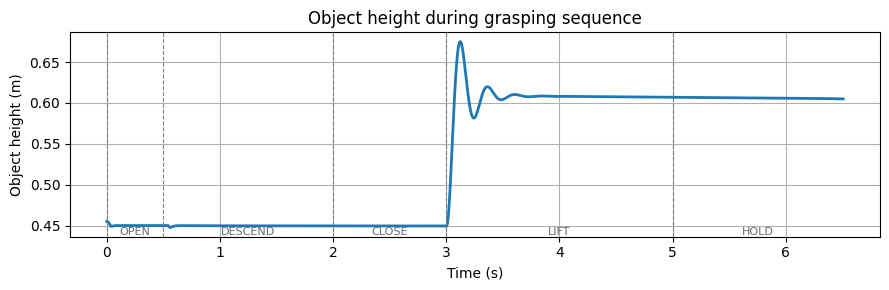

In [6]:
# Re-run simulation collecting (time, z) pairs
mujoco.mj_resetData(model, data)
times, obj_zs = [], []

for phase_name, z_tgt, l_tgt, r_tgt, duration in PHASES:
    t_end = data.time + duration
    while data.time < t_end:
        set_ctrl(z_tgt, l_tgt, r_tgt)
        mujoco.mj_step(model, data)
        times.append(data.time)
        obj_zs.append(object_z())

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(times, obj_zs, lw=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Object height (m)')
ax.set_title('Object height during grasping sequence')
ax.grid(True)

# annotate phase transitions
t_cur = 0
for pname, _, _, _, dur in PHASES:
    ax.axvline(t_cur, color='gray', lw=0.8, ls='--')
    ax.text(t_cur + dur/2, ax.get_ylim()[0] + 0.002, pname,
            ha='center', fontsize=8, color='dimgray')
    t_cur += dur

plt.tight_layout()
plt.show()